<a href="https://colab.research.google.com/github/asmalatif03084-spec/Data-Science/blob/main/Copy_of_Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q kaggle
from google.colab import files
files.upload()

Saving kaggle (1).json to kaggle (1).json


{'kaggle (1).json': b'{"username":"asma4321","key":"4ef2993bc24aad6728d2f432bb0d2042"}'}

In [2]:
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
print("key saved")

cp: cannot stat 'kaggle.json': No such file or directory
key saved


In [3]:
!kaggle datasets download -d andrewmvd/face-mask-detection
!unzip -q face-mask-detection.zip -d /content/data
!ls /content/data

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/face-mask-detection
License(s): CC0-1.0
100% 398M/398M [00:22<00:00, 18.5MB/s]

annotations  images


In [4]:
import glob
print("images:", len(glob.glob('/content/data/images/*')))
print("labels:", len(glob.glob('/content/data/annotations/*')))
print(open(glob.glob('/content/data/annotations/*.xml')[0]).read()[:600])

images: 853
labels: 853

<annotation>
    <folder>images</folder>
    <filename>maksssksksss177.png</filename>
    <size>
        <width>400</width>
        <height>300</height>
        <depth>3</depth>
    </size>
    <segmented>0</segmented>
    <object>
        <name>with_mask</name>
        <pose>Unspecified</pose>
        <truncated>0</truncated>
        <occluded>0</occluded>
        <difficult>0</difficult>
        <bndbox>
            <xmin>276</xmin>
            <ymin>76</ymin>
            <xmax>324</xmax>
            <ymax>118</ymax>
        </bndbox>
    </object>
    <object>
        <name>with_mask</name


In [5]:
import os, glob, random, shutil
import xml.etree.ElementTree as ET

CLASSES = ['with_mask', 'without_mask', 'mask_weared_incorrect']
SRC_IMG, SRC_ANN = '/content/data/images', '/content/data/annotations'
DST, EXT = '/content/dataset', '.png'

for s in ['train', 'val', 'test']:
    os.makedirs(f'{DST}/images/{s}', exist_ok=True)
    os.makedirs(f'{DST}/labels/{s}', exist_ok=True)

def convert(xml_path, out_txt):
    root = ET.parse(xml_path).getroot()
    w, h = int(root.find('size/width').text), int(root.find('size/height').text)
    lines = []
    for obj in root.findall('object'):
        name = obj.find('name').text
        if name not in CLASSES: continue
        b = obj.find('bndbox')
        x1, y1, x2, y2 = [float(b.find(k).text) for k in ('xmin','ymin','xmax','ymax')]
        lines.append(f"{CLASSES.index(name)} {((x1+x2)/2)/w:.6f} {((y1+y2)/2)/h:.6f} "
                     f"{(x2-x1)/w:.6f} {(y2-y1)/h:.6f}")
    open(out_txt, 'w').write('\n'.join(lines))

xmls = sorted(glob.glob(f'{SRC_ANN}/*.xml'))
random.seed(42); random.shuffle(xmls)
n = len(xmls); tr, va = int(n*0.8), int(n*0.9)
splits = {'train': xmls[:tr], 'val': xmls[tr:va], 'test': xmls[va:]}

for s, items in splits.items():
    for xml in items:
        stem = os.path.splitext(os.path.basename(xml))[0]
        shutil.copy(f'{SRC_IMG}/{stem}{EXT}', f'{DST}/images/{s}/{stem}{EXT}')
        convert(xml, f'{DST}/labels/{s}/{stem}.txt')

open(f'{DST}/data.yaml', 'w').write(f"""path: {DST}
train: images/train
val: images/val
test: images/test
names:
  0: with_mask
  1: without_mask
  2: mask_weared_incorrect
""")
print({k: len(v) for k, v in splits.items()})

{'train': 682, 'val': 85, 'test': 86}


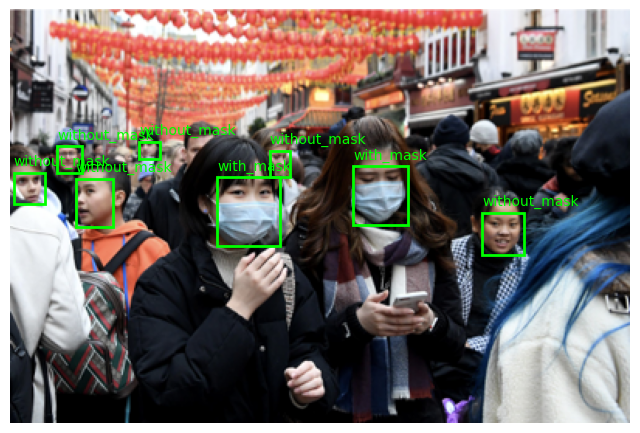

In [6]:
import matplotlib.pyplot as plt, matplotlib.patches as patches
from PIL import Image

p = sorted(glob.glob('/content/dataset/images/train/*'))[5]
lp = p.replace('/images/', '/labels/').rsplit('.',1)[0] + '.txt'
img = Image.open(p); W, H = img.size

fig, ax = plt.subplots(figsize=(8,8)); ax.imshow(img)
for line in open(lp).read().split('\n'):
    if not line.strip(): continue
    c, xc, yc, bw, bh = map(float, line.split())
    ax.add_patch(patches.Rectangle(((xc-bw/2)*W, (yc-bh/2)*H), bw*W, bh*H,
                 fill=False, color='lime', linewidth=2))
    ax.text((xc-bw/2)*W, (yc-bh/2)*H-5, CLASSES[int(c)], color='lime')
plt.axis('off'); plt.show()

In [7]:
!pip install -q ultralytics
from ultralytics import YOLO

m8 = YOLO('yolov8n.pt')
m8.train(data='/content/dataset/data.yaml', epochs=50, imgsz=640,
         batch=16, name='yolov8n_run')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 76.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 7.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics 8.4.150 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=T

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fd0bce873f0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [8]:
from google.colab import files
files.download('/content/runs/detect/yolov8n_run/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
!pip install -q gradio
print("done")

done


In [ ]:
import gradio as gr
from ultralytics import YOLO

model = YOLO('/content/runs/detect/yolov8n_run/weights/best.pt')

def detect(img, conf):
    if img is None:
        return None, "Please upload an image first"
    res = model.predict(img, conf=conf, verbose=False)[0]
    annotated = res.plot()[:, :, ::-1]          # convert BGR to RGB

    counts = {}
    lines = []
    for b in res.boxes:
        name = res.names[int(b.cls)]
        counts[name] = counts.get(name, 0) + 1
        lines.append(f"{name}  —  {float(b.conf):.2f}")

    if not lines:
        return annotated, "Nothing detected. Try lowering the confidence slider."

    summary = "TOTAL FACES: " + str(len(res.boxes)) + "\n"
    for k, v in counts.items():
        summary += f"{k}: {v}\n"
    return annotated, summary + "\n---\n" + "\n".join(lines)

gr.Interface(
    fn=detect,
    inputs=[gr.Image(type='numpy', label='Upload an image'),
            gr.Slider(0.1, 0.9, value=0.25, step=0.05, label='Confidence threshold')],
    outputs=[gr.Image(label='Detections'),
             gr.Textbox(label='Results', lines=10)],
    title='Face Mask Detection — YOLOv8n',
    description='Upload any photo. Green boxes show detected faces with their mask status.'
).launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://88ead663d7ee95fac4.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
